In [2]:
import sys
sys.path.append("../")
import opendssdirect as dss
import yadi.hc.model.vc as dss_vc_hc

In [3]:
import numpy as np
import opendssdirect as dss
import matplotlib.pyplot as plt
import seaborn as sns
import yadi.dss.model as dss_model
import yadi.dss.sensitivity as dss_sens
import yadi.dss.qsts as dss_qsts

In [4]:
#Setup plot aesthetics
import matplotlib
%matplotlib inline
matplotlib.rc('text', usetex=True)
matplotlib.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb}')
sns.set_theme(context='paper',style='ticks')

In [12]:
cktfile = "./../test_cases/13Bus/IEEE13Nodeckt.dss"
sens = dss_sens.DSS_Sensitivities(cktfile,verbose=False)
#Get the taylor coefficients
dvdp = sens.get_svp()
dvdq = sens.get_svq()

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt


In [13]:
dss.Text.Command('Redirect ./../test_cases/13Bus/IEEE13Nodeckt.dss')
vph_base = dss.Circuit.AllBusMagPu()

In [51]:
svp,svq = dvdp["matrix"],dvdq["matrix"]
svp,svq = svp[9:,9:],svq[9:,9:]
svp,svq = svp[6:,6:],svq[6:,6:]
vbase_study = vph_base[9:]
vbase_study = vbase_study[6:]
n_study = svp.shape[0]
p_range = np.array([i for i in np.arange(start=1,stop=10000,step=0.1)])
vplus = np.zeros((len(p_range),n_study))
for i in range(n_study):
    vhat_i = [svp[:,i]*p_i for p_i in p_range]
    vhat_ii = [vi[i] for vi in vhat_i]
    vplus_ii = [vbase_study[i] + vii for vii in vhat_ii]
    vplus[:,i] = vplus_ii


<AxesSubplot:>

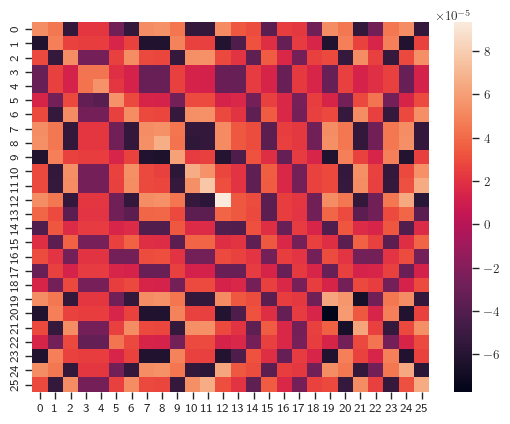

In [52]:
sns.heatmap(svp)

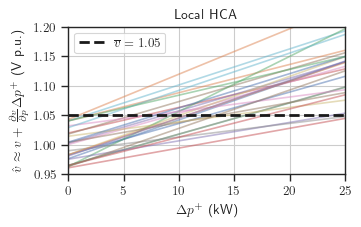

In [59]:
fig,ax= plt.subplots(figsize=(3.5,3.5/1.61828),constrained_layout=True)

ax.plot(p_range/100,vplus,alpha=0.5)
ax.axhline(1.05,ls='--',c='k',lw=2,label=r"$\overline{v} = 1.05$")
ax.grid()
ax.set_xlim(0,25)
ax.set_ylim(0.95,1.2)
ax.legend()
ax.set_xlabel("$\Delta p^{+}$ (kW)")
ax.set_ylabel(r"$\hat{v} \approx v + \frac{\partial v}{\partial p} \Delta p^{+}$ (V p.u.)")
ax.set_title("Local HCA")
plt.savefig("local_hca.pdf",dpi=400)
plt.savefig("local_hca.png",dpi=400)

In [ ]:
plt.plot(v_hat_1[])

In [3]:
redirects = ["./../test_cases/13Bus/IEEE13Nodeckt.dss"]
vchc = dss_vc_hc.DSS_VC_HCA(redirects)
hc = vchc.get_iterative_hc()

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt
DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt
DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeck

In [4]:
hc

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0.])

In [18]:
vph_base = dss.Circuit.AllBusMagPu()

In [19]:
sub_overvoltage_idx = [i for i in range(len(vph_base)) if vph_base[i]<1.05]

In [36]:
import numpy as np
np.any(np.asarray(vph_base) > 1.05)

True